In [ ]:
import sys
import os
# Add pipeline directory to sys.path to enable imports
sys.path.append(os.path.abspath('../pipeline'))


## Imports and Paths Configurations

In [ ]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

from helpers import (
    POSE_NAMES, SKELETON, ANGLE_COLUMNS, DEFAULT_POSE_MAP,
    calc_distance, calc_vector_angle, calc_arcsin_angle,
    compute_baselines, compute_frame_angles, compute_all_angles,
    anchor_interpolate, export_joints_and_angles,
    summarize_and_normalize, min_max_scale,
    load_mat_metadata, load_sequence_as_dataframe
)

In [2]:
DATASET_ROOT = '../Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '0955'

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)


frame_idx = 0

In [ ]:
# Joint names and skeleton connections are now imported from helpers.py
# POSE_NAMES, SKELETON, ANGLE_COLUMNS are available globally.

pose_names = POSE_NAMES
skeleton = SKELETON

## Example Sequence From the Data

## 1. Data Shaping & Normalization

The primary challenge with `.mat` structures in Python is that they often wrap single values or strings in multiple levels of lists (e.g., `[[ 'action_name' ]]`).

### Metadata Handling

To prevent the visualization from crashing or displaying ugly bracket-filled titles, we normalized the metadata:

- **The Problem:** MATLAB often stores strings as arrays of characters or nested lists.
    
- **The Fix:**
    
    - Accessed the base index `[0][0]` for scalars like `nframes`.
        
    - Used `isinstance(..., (list, np.ndarray))` checks to drill down into action names and viewpoints, ensuring we extract a clean string.
        

### Geometric Structures

The arrays for bounding boxes and joints are typically stored in a per-frame format:

- **Bounding Box (`bbox`):** Expected as a 1D array of four coordinates per frame: `[x_min, y_min, x_max, y_max]`.
    
- **Keypoints (`x`, `y`):** Two separate arrays where the $i^{th}$ index in each corresponds to the same joint.
    
- **Visibility:** A binary mask (0 or 1) indicating if a joint is occluded or out of frame. This is crucial for preventing the drawing of "ghost" joints at `(0,0)`.
    

---

## 2. File System Resilience

Datasets often use different zero-padding for image filenames (e.g., `0001.jpg` vs `000001.jpg`). Hardcoding one format usually breaks the script when switching sequences.

- **The Logic:** The function implements a **fall-through naming check**.
    
    - It first attempts a 6-digit padding (`:06d`).
        
    - If `os.path.exists` returns `False`, it falls back to 4-digit padding (`:04d`).
        
    - This makes the function "dataset-agnostic" for common computer vision benchmarks.
        

---

## 3. Jupyter Notebook Integration

Standard `cv2.imshow` often hangs or crashes inside a browser-based Jupyter environment. We "fixed" the playback experience using the following stack:

|**Component**|**Purpose**|
|---|---|
|**`cv2.cvtColor`**|Converts OpenCV's default BGR format to RGB for correct `matplotlib` colors.|
|**`plt.show()`**|Renders the frame directly in the notebook cell output.|
|**`clear_output`**|Clears the previous frame from the cell, creating a "video" effect instead of a long list of images.|
|**`time.sleep`**|Controls the playback speed (FPS) based on the `delay` parameter.|

In [3]:
def visualize_sequence(sequence_id, mat_data, frames_dir, delay=0.1):
    """
    Plays back a dataset sequence as a video inside a Jupyter Notebook,
    drawing bounding boxes and visible joint keypoints.
    
    Parameters:
    - sequence_id (str or int): The ID of the sequence folder (e.g., '1028').
    - mat_data (dict): The loaded .mat dictionary for this sequence.
    - frames_dir (str): The root directory where the frame folders are stored.
    - delay (float): Time in seconds to pause between frames (controls playback speed).
    """
    # Ensure sequence_id is a string for folder pathing
    seq_str = str(sequence_id)
    
    # 1. Extract Metadata
    n_frames = mat_data['nframes'][0][0]
    
    action_name = mat_data['action'][0]
    if isinstance(action_name, (list, np.ndarray)):
        action_name = action_name[0]

    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)):
        viewpoint = viewpoint[0] if len(viewpoint) > 0 else 'Unknown'

    # 2. Playback Loop
    for frame_idx in range(n_frames):
        bbox = mat_data['bbox'][frame_idx]
        joints_x = mat_data['x'][frame_idx]
        joints_y = mat_data['y'][frame_idx]
        visibility = mat_data['visibility'][frame_idx]

        # Try 6-digit format first, fallback to 4-digit if not found
        img_filename = f"{frame_idx + 1:06d}.jpg"
        img_path = os.path.join(frames_dir, seq_str, img_filename)
        
        if not os.path.exists(img_path):
            img_filename = f"{frame_idx + 1:04d}.jpg"
            img_path = os.path.join(frames_dir, seq_str, img_filename)

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not load {img_path}. Skipping...")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Draw Bounding Box and Keypoints
        cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
        for i in range(len(joints_x)):
            if visibility[i] == 1:
                cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

        # 4. Display the frame
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Seq: {seq_str} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
        plt.axis('off')
        plt.show()
        
        # Pause and clear
        time.sleep(delay) 
        clear_output(wait=True)

In [18]:
def draw_stabilized_pose_on_image(img, joints_x, joints_y, vis, pose_names, skeleton):
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])),
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1)
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
    return img


def visualize_stabilized_sequence(sequence_id, mat_data, df, frames_dir, delay=0.1):
    n_frames = mat_data['nframes'][0][0]

    for frame_idx in range(n_frames):
        vis = mat_data['visibility'][frame_idx].copy()
        joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
        joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

        img_filename = f"{frame_idx + 1:06d}.jpg"
        img_path = os.path.join(frames_dir, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None:
            img_filename = f"{frame_idx + 1:04d}.jpg"
            img_path = os.path.join(frames_dir, sequence_id, img_filename)
            img = cv2.imread(img_path)
            if img is None:
                continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = draw_stabilized_pose_on_image(img, joints_x, joints_y, vis, pose_names, skeleton)

        clear_output(wait=True)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
        plt.axis('off')
        plt.show()

        time.sleep(delay)

## Basic Geometry Functions

In [ ]:
# --- Helper Kinematic Functions ---
# calc_distance, calc_vector_angle, calc_arcsin_angle
# are now imported from helpers.py (see imports cell above).
# 
# Additional helpers available:
#   compute_baselines(stand_row)       — computes all 10 baseline distances
#   compute_frame_angles(row, ...)     — computes 8 angles for a single frame
#   compute_all_angles(df, ...)        — computes angles for all frames
#   anchor_interpolate(df)             — head-anchored relative interpolation
#   export_joints_and_angles(...)      — exports joints/angles CSVs
#   summarize_and_normalize(action)    — full summary pipeline
#   load_mat_metadata(mat_data)        — extracts n_frames, action, viewpoint
#   load_sequence_as_dataframe(...)    — loads sequence into DataFrame

# Feature Extraction Example

# Jump-Rope

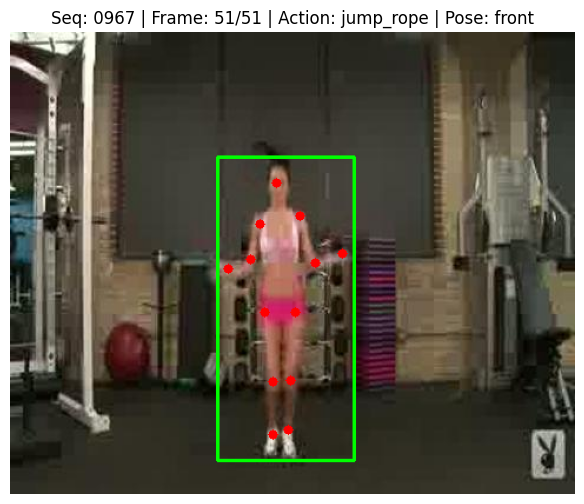

In [14]:
sequence_id = '0967'

frame_idx = 0

mat_data = sio.loadmat(os.path.join(LABELS_DIR, f'{sequence_id}.mat'))

visualize_sequence(sequence_id, mat_data, FRAMES_DIR, delay=0.1)

# Preprocessing: Rigid Torso & Symmetry Stabilization

The goal of this pipeline is to transform raw, incomplete `.mat` labels into a temporally consistent skeleton suitable for training or kinematic analysis.

---

### 1. The "Flying Head" Problem (Rigid Torso Fix)
In jump rope sequences, the head often disappears or "teleports" due to rapid vertical movement. Since the torso is physically a rigid structure, we use the **Hips** (which are usually more stable) to anchor the head.

* **Mid-Hip Anchor:** We calculate a `Mid_Hip` point as the average of the Left and Right Hip.
* **True Torso Length:** We calculate the median distance ($x, y$ offsets) between the head and the mid-hip across frames where both are visible. This establishes a "biometric constant" for the subject.
* **Head Reconstruction:** For frames where the head is missing, we project its position relative to the moving hips using the calculated `true_torso` vector.

### 2. Side-Profile Kinematics & Symmetry
Jump rope actions are often filmed from a side or 45-degree profile, causing one side of the body to occlude the other.

* **Mirroring (L/R Symmetry):** If one joint is missing (e.g., Left Knee) but its counterpart (Right Knee) is visible, we copy the coordinates. This assumes symmetry, which is a high-probability state during a jump rope cycle.
* **Synthetic Limb Construction:** For frames where entire limb segments are missing, we use kinematic heuristics based on the torso length:
    * **Shoulders:** Placed at **20%** of the torso length below the head.
    * **Elbows/Wrists:** Positioned in a default "ready" posture (offset from the shoulders) to maintain a valid skeleton for the model, even when joints are invisible.

### 3. Anchor-Based Relative Interpolation
Standard linear interpolation on raw $x, y$ coordinates often leads to "drifting" joints during fast jumps. 

**The Fix:** We convert all joint coordinates to be relative to the Head:

$$Joint_{rel} = Joint_{absolute} - Head_{absolute}$$

We interpolate the relative offsets and then reconstruct the absolute positions. This ensures that even if the person is jumping, the limbs move **with** the body during the gap-fill rather than sliding across the screen.

---

### Visual Output Legend
To verify the "fix" during playback, the visualization distinguishes between original and generated data:

| Element | Visualization Logic | Meaning |
| :--- | :--- | :--- |
| **Green Dot** | `visibility == 1` | **Ground Truth:** Data provided by the original dataset. |
| **Red Dot** | `visibility == 0` | **Predicted:** Joint reconstructed via rigid torso logic or symmetry. |
| **Cyan Lines** | `skeleton` | **Connectivity:** Visualizes the bone structure to ensure no "broken" limbs. |
| **Asterisk (*)** | `*JointName` | Label indicating a joint that was missing in the raw data. |

In [19]:
def preprocess_sequence(sequence_id, labels_dir):
    """Load a sequence .mat file and apply rigid torso / symmetry stabilization."""
    seq_str = str(sequence_id)
    mat_path = os.path.join(labels_dir, f'{seq_str}.mat')
    mat_data = sio.loadmat(mat_path)
    n_frames = mat_data['nframes'][0][0]

    # STEP 1: LOAD ALL FRAMES
    raw_data = []
    for f in range(n_frames):
        jx = mat_data['x'][f].astype(float)
        jy = mat_data['y'][f].astype(float)
        vis = mat_data['visibility'][f]

        row = {}
        for i in range(13):
            if vis[i] == 1:
                row[f'{pose_names[i]}_x'] = jx[i]
                row[f'{pose_names[i]}_y'] = jy[i]
            else:
                row[f'{pose_names[i]}_x'] = np.nan
                row[f'{pose_names[i]}_y'] = np.nan
        raw_data.append(row)

    df = pd.DataFrame(raw_data)

    # STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
    df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
    df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

    valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
    if not valid_torso.empty:
        true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
        true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
    else:
        true_torso_y = 150.0
        true_torso_x = 0.0

    for f in range(n_frames):
        if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
            df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
            df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

    df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

    # STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
    for f in range(n_frames):
        head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']

        for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
            r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
            l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'

            if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
                df.at[f, l_y] = df.at[f, r_y]
                df.at[f, l_x] = df.at[f, r_x]
            elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
                df.at[f, r_y] = df.at[f, l_y]
                df.at[f, r_x] = df.at[f, l_x]

        if pd.isna(df.at[f, 'R_Sho_y']):
            sho_y = head_y + (true_torso_y * 0.2)
            sho_x = head_x
            df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
            df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x

        if pd.isna(df.at[f, 'R_Elb_y']):
            elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
            elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
            df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
            df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x

        if pd.isna(df.at[f, 'R_Wri_y']):
            wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
            wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
            df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
            df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

    # STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
    for name in pose_names[1:]:
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

    for name in pose_names[1:]:
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

    for name in pose_names[1:]:
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

    return mat_data, df

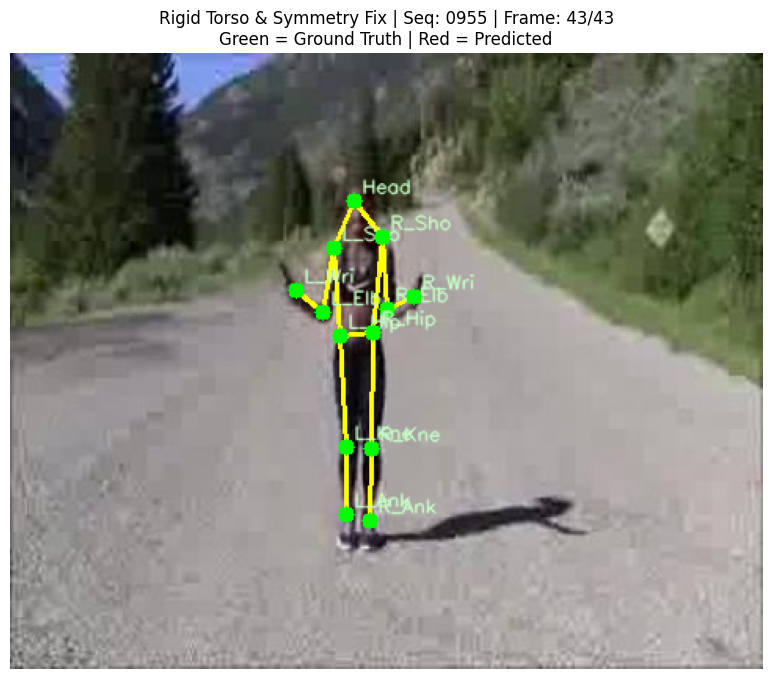

In [20]:
sequence_id = '0955'  # The sequence with the "flying" head
mat_data, df = preprocess_sequence(sequence_id, LABELS_DIR)
visualize_stabilized_sequence(sequence_id, mat_data, df, FRAMES_DIR, delay=0.1)

In [ ]:


all_joints_data = []
all_angles_data = []

print("Starting batch process for Jump Rope sequences...")

for seq_num in range(1, 2327):
    sequence_id = f"{seq_num:04d}"
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    if not os.path.exists(mat_path): continue
        
    mat_data = sio.loadmat(mat_path)
    action_str = str(mat_data['action']).lower()
    
    # Target jump rope sequences ('jumprope' is often how it's labeled in Penn Action)
    if 'jump' not in action_str and 'rope' not in action_str: continue
        
    n_frames = mat_data['nframes'][0][0]

    # 1. LOAD RAW DATA
    raw_rows = []
    for f in range(n_frames):
        row = {'Sequence_ID': sequence_id, 'Frame': f + 1}
        jx, jy, vis = mat_data['x'][f], mat_data['y'][f], mat_data['visibility'][f]
        for i, name in enumerate(pose_names):
            if vis[i] == 1:
                row[f'{name}_x'], row[f'{name}_y'] = float(jx[i]), float(jy[i])
            else:
                row[f'{name}_x'], row[f'{name}_y'] = np.nan, np.nan
        raw_rows.append(row)
    df = pd.DataFrame(raw_rows)

    # 2. PREDICT MISSING POINTS (Using your exact method)
    df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
    df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

    valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
    if not valid_torso.empty:
        true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
        true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
    else:
        true_torso_y, true_torso_x = 150.0, 0.0

    for f in range(n_frames):
        if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
            df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
            df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

    df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

    for f in range(n_frames):
        head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
        
        # Enforce L/R Symmetry
        for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
            ry, rx, ly, lx = f'R_{joint}_y', f'R_{joint}_x', f'L_{joint}_y', f'L_{joint}_x'
            if not pd.isna(df.at[f, ry]) and pd.isna(df.at[f, ly]):
                df.at[f, ly], df.at[f, lx] = df.at[f, ry], df.at[f, rx]
            elif not pd.isna(df.at[f, ly]) and pd.isna(df.at[f, ry]):
                df.at[f, ry], df.at[f, rx] = df.at[f, ly], df.at[f, lx]

        # Build Missing Arms Parallel
        if pd.isna(df.at[f, 'R_Sho_y']):
            df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = head_y + (true_torso_y * 0.2)
            df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = head_x
        if pd.isna(df.at[f, 'R_Elb_y']):
            df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
            df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        if pd.isna(df.at[f, 'R_Wri_y']):
            df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
            df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)

    # Anchor-Based Relative Interpolation
    for name in pose_names[1:]: 
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

    # Store predicted joints
    joint_cols = ['Sequence_ID', 'Frame'] + [f'{n}_x' for n in pose_names] + [f'{n}_y' for n in pose_names]
    all_joints_data.append(df[joint_cols].copy().round(3))

    # 3. KINEMATICS & ANGLE CALCULATIONS
    # Determine Viewpoint
    avg_sw = abs(df['L_Sho_x'] - df['R_Sho_x']).mean()
    avg_th = abs(df[['L_Sho_y', 'R_Sho_y']].mean(axis=1) - df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)).mean()
    pose_type = 'Front/Back' if avg_sw > (avg_th * 0.45) else 'Side'

    # Find Standing Frame for Baseline
    df['Mid_Ank_y'] = df[['L_Ank_y', 'R_Ank_y']].mean(axis=1)
    df['Total_Height'] = abs(df['Head_y'] - df['Mid_Hip_y']) + abs(df['Mid_Hip_y'] - df['Mid_Ank_y'])
    if df['Total_Height'].isna().all(): df['Total_Height'] = abs(df['Head_y'] - df['Mid_Hip_y'])
    
    stand_idx = df['Total_Height'].idxmax() if not df['Total_Height'].isna().all() else 0
    stand_row = df.iloc[stand_idx]

    # Calculate Baselines for Arcsin Method
    base = compute_baselines(stand_row)

    all_angles_data.extend(compute_all_angles(df, sequence_id, pose_type, base))

    if seq_num % 100 == 0: print(f"Processed up to {sequence_id}...")

# EXPORT
export_joints_and_angles(all_joints_data, all_angles_data, 'jump_rope')

In [ ]:
# Summarize and normalize jump rope data
# (Replaces ~60 lines of repeated code with a single function call)
summarize_and_normalize('jump_rope')

# Squat


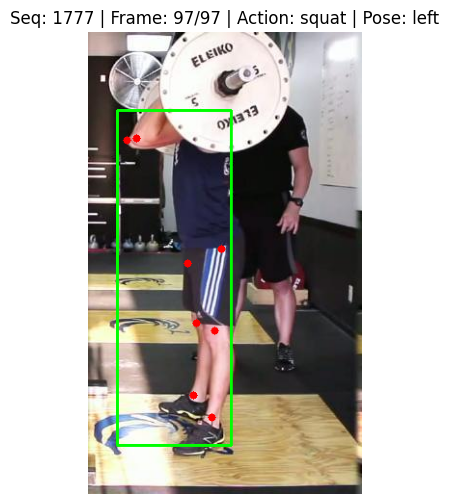

In [ ]:
sequence_id = '1777'  

frame_idx = 0

mat_data = sio.loadmat(os.path.join(LABELS_DIR, f'{sequence_id}.mat'))

visualize_sequence(sequence_id, mat_data, FRAMES_DIR, delay=0.1)

## Preprocessing: Kinematic Stabilization for Squat Depth

In squat sequences, the primary issue is the **occlusion of the head and hips** during the maximum depth phase, and the **overlapping of limbs** in a side-profile view.

### 1. The "Flying Head" & Torso Compression (Step 1.5)

During a squat, the distance between the head and hips changes dynamically in 3D space, but in a 2D projection, the head can often be lost against the background or "jitter" due to labeling inconsistency.

- **Mid-Hip Baseline:** We establish a central anchor between the `L_Hip` and `R_Hip`. This serves as the "root" of the human movement.
    
- **Rigid Torso Approximation:** By calculating the median distance between the head and the mid-hip during the standing phases (where both are visible), we create a **rigid constraint**.
    
- **Vertical Reconstruction:** If the head is occluded by the camera angle at the bottom of the squat, the script "re-attaches" the head to the torso based on the hip position, preventing the skeleton from collapsing.
    

### 2. Side-Profile Symmetry & Occlusion (Step 1.6)

Squats are frequently recorded from the side to monitor form. This leads to "Self-Occlusion," where the left leg perfectly hides the right leg.

- **L/R Symmetry Enforcement:** If the labeler only marked the visible side (e.g., `L_Knee`), the script automatically mirrors those coordinates to the occluded side (`R_Knee`). This creates a complete 13-joint skeleton necessary for neural network input.
    
- **Proportional Arm Placement:** If the arms are not labeled (common in datasets focusing on lower-body power), the script builds **synthetic arms**.
    
    - **Shoulders** are placed relative to the head.
        
    - **Elbows and Wrists** are projected using torso-length fractions (35% and 10% respectively) to maintain a realistic "balancing" posture typical of a squat.
        

### 3. Anchor-Based Relative Interpolation (Step 2)

In a squat, the "action" is the relative change between joints, not just their absolute screen position.

- **Relative Mapping:** We shift the coordinate system so every joint is defined as an $(x, y)$ offset from the **Head**.
    
- **Smooth Descent:** Linear interpolation is performed on these _relative_ values. This ensures that if the subject is descending, the missing joints follow a smooth downward arc relative to the head, rather than cutting a straight line across the image which would look physically impossible.
    

---

## Visualization Legend for Squat Analysis

The playback provides a visual audit of the reconstruction quality:

|**Feature**|**Visualization**|**Role in Squat Sequence**|
|---|---|---|
|**Green Markers**|Ground Truth|Original labeled data (usually the "up" position).|
|**Red Markers**|Predicted ($*$)|Reconstructed joints (usually the "down" or occluded position).|
|**Cyan Skeleton**|Skeleton Lines|Shows the angle of the femur and spine (critical for squat form).|
|**Rigid Torso**|Title Indicator|Confirms the head-to-hip distance is being maintained.|

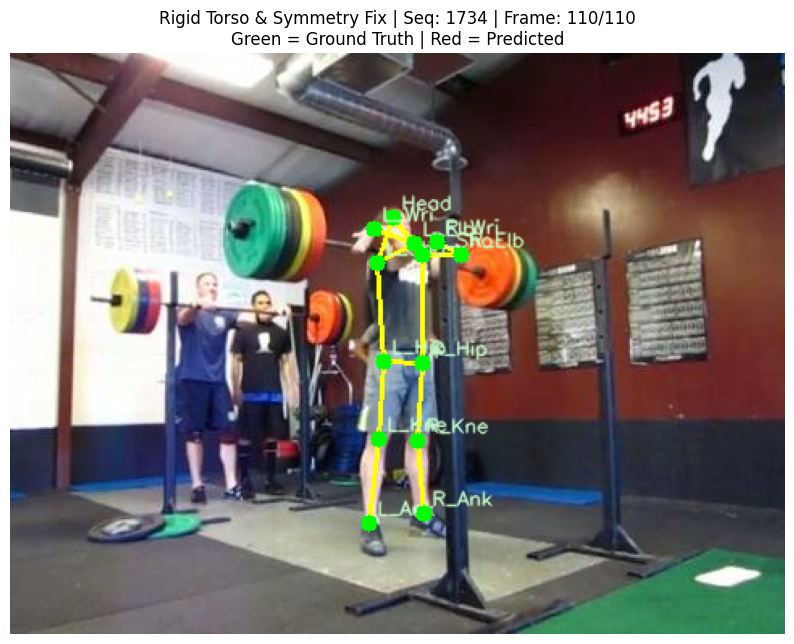

In [ ]:
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1734' # The sequence with the "flying" head

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]



# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

In [ ]:

LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- Data Containers ---
all_joints_data = []
all_angles_data = []

print("Starting batch process for Squat sequences...")

# Processing full range (adjust if you only want a subset)
for seq_num in range(1, 2327):
    sequence_id = f"{seq_num:04d}"
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    if not os.path.exists(mat_path): continue
        
    mat_data = sio.loadmat(mat_path)
    # Robust action check
    action_str = str(mat_data['action']).lower()
    if 'squat' not in action_str: continue
        
    n_frames = mat_data['nframes'][0][0]

    # 1. LOAD DATA
    raw_rows = []
    for f in range(n_frames):
        row = {'Sequence_ID': sequence_id, 'Frame': f + 1}
        jx, jy, vis = mat_data['x'][f], mat_data['y'][f], mat_data['visibility'][f]
        for i, name in enumerate(pose_names):
            if vis[i] == 1:
                row[f'{name}_x'], row[f'{name}_y'] = float(jx[i]), float(jy[i])
            else:
                row[f'{name}_x'], row[f'{name}_y'] = np.nan, np.nan
        raw_rows.append(row)
    df = pd.DataFrame(raw_rows)

    # 2. PREDICT MISSING POINTS (Rigid Torso & Symmetry)
    df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
    df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)
    
    valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
    true_ty = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median() if not valid_torso.empty else 150.0
    true_tx = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median() if not valid_torso.empty else 0.0

    for f in range(n_frames):
        if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
            df.at[f, 'Head_y'], df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_y'] - true_ty, df.at[f, 'Mid_Hip_x'] - true_tx
    
    df['Head_x'] = df['Head_x'].interpolate(limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(limit_direction='both')

    # Symmetry & Proportional builds
    for f in range(n_frames):
        hy, hx = df.at[f, 'Head_y'], df.at[f, 'Head_x']
        for j in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
            ry, rx, ly, lx = f'R_{j}_y', f'R_{j}_x', f'L_{j}_y', f'L_{j}_x'
            if not pd.isna(df.at[f, ry]) and pd.isna(df.at[f, ly]):
                df.at[f, ly], df.at[f, lx] = df.at[f, ry], df.at[f, rx]
            elif not pd.isna(df.at[f, ly]) and pd.isna(df.at[f, ry]):
                df.at[f, ry], df.at[f, rx] = df.at[f, ly], df.at[f, lx]
        
        if pd.isna(df.at[f, 'R_Sho_y']):
            df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = hy + (true_ty * 0.2)
            df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = hx

    # Anchor-based Relative Interpolation
    for name in pose_names[1:]: 
        df[f'{name}_x'] = (df[f'{name}_x'] - df['Head_x']).interpolate(limit_direction='both') + df['Head_x']
        df[f'{name}_y'] = (df[f'{name}_y'] - df['Head_y']).interpolate(limit_direction='both') + df['Head_y']

    # Store joints
    joint_cols = ['Sequence_ID', 'Frame'] + [f'{n}_x' for n in pose_names] + [f'{n}_y' for n in pose_names]
    all_joints_data.append(df[joint_cols].copy().round(3))

    # 3. KINEMATICS & STANDING FRAME
    avg_sw = abs(df['L_Sho_x'] - df['R_Sho_x']).mean()
    avg_th = abs(df[['L_Sho_y', 'R_Sho_y']].mean(axis=1) - df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)).mean()
    pose_type = 'Front/Back' if avg_sw > (avg_th * 0.45) else 'Left/Right'

    df['Mid_Ank_y'] = df[['L_Ank_y', 'R_Ank_y']].mean(axis=1)
    df['Height'] = abs(df['Head_y'] - df['Mid_Hip_y']) + abs(df['Mid_Hip_y'] - df['Mid_Ank_y'])
    if df['Height'].isna().all(): df['Height'] = abs(df['Head_y'] - df['Mid_Hip_y'])
    
    stand_idx = df['Height'].idxmax() if not df['Height'].isna().all() else 0
    sr = df.iloc[stand_idx]
    
    # Baselines
    base = {
        'L_SH': calc_distance(sr, 'L_Sho', 'L_Hip'), 'L_HK': calc_distance(sr, 'L_Hip', 'L_Kne'),
        'L_KA': calc_distance(sr, 'L_Kne', 'L_Ank'), 'L_SE': calc_distance(sr, 'L_Sho', 'L_Elb'),
        'L_EW': calc_distance(sr, 'L_Elb', 'L_Wri'), 'R_SH': calc_distance(sr, 'R_Sho', 'R_Hip'),
        'R_HK': calc_distance(sr, 'R_Hip', 'R_Kne'), 'R_KA': calc_distance(sr, 'R_Kne', 'R_Ank'),
        'R_SE': calc_distance(sr, 'R_Sho', 'R_Elb'), 'R_EW': calc_distance(sr, 'R_Elb', 'R_Wri')
    }

    for idx, row in df.iterrows():
        ang = {'Sequence_ID': sequence_id, 'Frame': row['Frame'], 'Pose': pose_type}
        if pose_type == 'Front/Back':
            # Arcsin Method (Your method for front)
            ang['L_Shoulder_Angle'] = calc_arcsin_angle(calc_distance(row, 'L_Hip', 'L_Sho'), base['L_SH'], calc_distance(row, 'L_Sho', 'L_Elb'), base['L_SE'])
            ang['R_Shoulder_Angle'] = calc_arcsin_angle(calc_distance(row, 'R_Hip', 'R_Sho'), base['R_SH'], calc_distance(row, 'R_Sho', 'R_Elb'), base['R_SE'])
            ang['L_Elbow_Angle'] = calc_arcsin_angle(calc_distance(row, 'L_Sho', 'L_Elb'), base['L_SE'], calc_distance(row, 'L_Elb', 'L_Wri'), base['L_EW'])
            ang['R_Elbow_Angle'] = calc_arcsin_angle(calc_distance(row, 'R_Sho', 'R_Elb'), base['R_SE'], calc_distance(row, 'R_Elb', 'R_Wri'), base['R_EW'])
            ang['L_Hip_Angle'] = calc_arcsin_angle(calc_distance(row, 'L_Sho', 'L_Hip'), base['L_SH'], calc_distance(row, 'L_Hip', 'L_Kne'), base['L_HK'])
            ang['R_Hip_Angle'] = calc_arcsin_angle(calc_distance(row, 'R_Sho', 'R_Hip'), base['R_SH'], calc_distance(row, 'R_Hip', 'R_Kne'), base['R_HK'])
            ang['L_Knee_Angle'] = calc_arcsin_angle(calc_distance(row, 'L_Hip', 'L_Kne'), base['L_HK'], calc_distance(row, 'L_Kne', 'L_Ank'), base['L_KA'])
            ang['R_Knee_Angle'] = calc_arcsin_angle(calc_distance(row, 'R_Hip', 'R_Kne'), base['R_HK'], calc_distance(row, 'R_Kne', 'R_Ank'), base['R_KA'])
        else:
            # Vector Method (Side method)
            ang['L_Shoulder_Angle'] = calc_vector_angle(row, 'L_Hip', 'L_Sho', 'L_Elb')
            ang['R_Shoulder_Angle'] = calc_vector_angle(row, 'R_Hip', 'R_Sho', 'R_Elb')
            ang['L_Elbow_Angle'] = calc_vector_angle(row, 'L_Sho', 'L_Elb', 'L_Wri')
            ang['R_Elbow_Angle'] = calc_vector_angle(row, 'R_Sho', 'R_Elb', 'R_Wri')
            ang['L_Hip_Angle'] = calc_vector_angle(row, 'L_Sho', 'L_Hip', 'L_Kne')
            ang['R_Hip_Angle'] = calc_vector_angle(row, 'R_Sho', 'R_Hip', 'R_Kne')
            ang['L_Knee_Angle'] = calc_vector_angle(row, 'L_Hip', 'L_Kne', 'L_Ank')
            ang['R_Knee_Angle'] = calc_vector_angle(row, 'R_Hip', 'R_Kne', 'R_Ank')
        
        for k in ang: 
            if 'Angle' in k and not pd.isna(ang[k]): ang[k] = round(ang[k], 2)
        all_angles_data.append(ang)

    if seq_num % 100 == 0: print(f"Processed {seq_num} sequences...")

# 4. EXPORT
if all_angles_data:
    pd.concat(all_joints_data, ignore_index=True).to_csv('squat_joints.csv', index=False)
    cols = ['Sequence_ID', 'Frame', 'Pose', 'L_Shoulder_Angle', 'R_Shoulder_Angle', 'L_Elbow_Angle', 'R_Elbow_Angle', 'L_Hip_Angle', 'R_Hip_Angle', 'L_Knee_Angle', 'R_Knee_Angle']
    pd.DataFrame(all_angles_data).reindex(columns=cols).to_csv('squat_angles.csv', index=False)
    print("Success! Files saved: squat_joints.csv, squat_angles.csv")
else:
    print("No squat sequences found.")

Starting batch process for Squat sequences...
Processed 1700 sequences...
Processed 1800 sequences...
Success! Files saved: squat_joints.csv, squat_angles.csv


In [ ]:
# Summarize and normalize squat data
summarize_and_normalize('squat')

In [ ]:
# Squat normalization already handled by summarize_and_normalize() above.
# This cell is no longer needed.

# Bowl

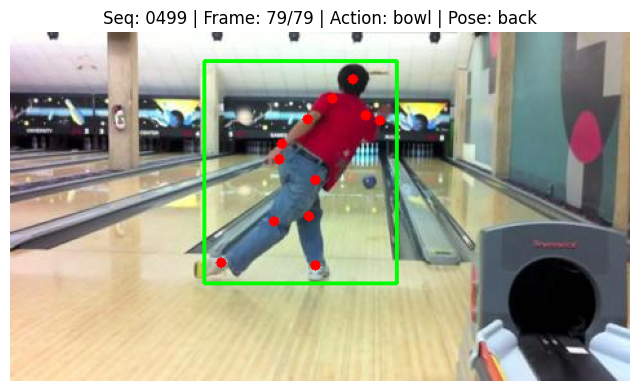

In [ ]:
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '0499'  # Change to your desired sequence ID 



mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]

# Extract Action
action_name = mat_data['action'][0]
if isinstance(action_name, (list, np.ndarray)):
    action_name = action_name[0]

# Extract Viewpoint/Pose (front, back, left, right)
viewpoint = mat_data.get('pose', ['Unknown'])[0]
if isinstance(viewpoint, (list, np.ndarray)):
    if len(viewpoint) > 0:
        viewpoint = viewpoint[0]
    else:
        viewpoint = 'Unknown'

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg" 
    # Fallback for 4-digit formatting if needed: img_filename = f"{frame_idx + 1:04d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # Write the Viewpoint on the image itself (Top Left Corner)
    # text_to_display = f"Viewpoint: {viewpoint}"
    # cv2.putText(img, text_to_display, (15, 35), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2, cv2.LINE_AA)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Also add the viewpoint to the matplotlib title
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

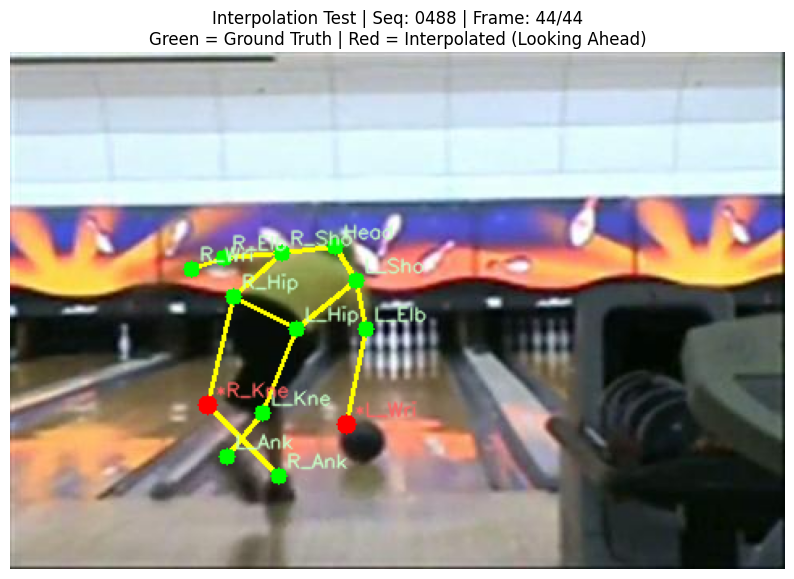

In [ ]:
sequence_id = '0488' # A bowling sequence

n_frames = mat_data['nframes'][0][0]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            # If missing, mark as Not a Number (NaN)
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 2: THE MAGIC - INTERPOLATE MISSING DATA
# ==========================================
# This looks at the point before it disappeared, and the point after it reappeared,
# and calculates the exact straight-line path between them frame-by-frame.
# 'limit_direction=both' handles edges (if it's missing at frame 0, it pulls the first known point backward).
df_interp = df.interpolate(method='linear', limit_direction='both')


# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    # Grab the newly calculated interpolated coordinates for this frame
    joints_x = [df_interp.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df_interp.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    # Load Image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines 
    for (j1, j2) in skeleton:
        # Check that we aren't drawing lines to 0.0 (in case a joint was NEVER visible in the whole video)
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED joints via Interpolation in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Interpolation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Interpolated (Looking Ahead)")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

# Pushup

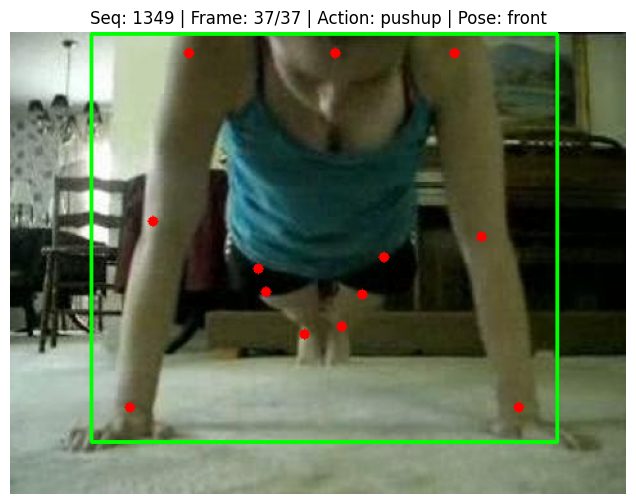

In [ ]:
# 1. Find a 'squat' sequence with a 'front' viewpoint
target_actions = ['pushup']
target_viewpoint = 'front'
sequence_id = None
action_name = None

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    # Extract Action
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    
    # Extract Viewpoint
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = viewpoint[0]
        
    if action in target_actions and viewpoint == target_viewpoint:
        sequence_id = label_file.split('.')[0]
        action_name = action
        break

if sequence_id is None:
    print(f"Could not find any sequence for {target_actions} with viewpoint '{target_viewpoint}'.")
else:
    print(f"Found Sequence: {sequence_id} | Action: {action_name} | Pose: {target_viewpoint}")
    
    # Load data for the found sequence
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    mat_data = sio.loadmat(mat_path)

    # Get the total number of frames from the loaded .mat file
    n_frames = mat_data['nframes'][0][0]

    for frame_idx in range(n_frames):
        # 1. Extract annotations for the current frame
        bbox = mat_data['bbox'][frame_idx]
        joints_x = mat_data['x'][frame_idx]
        joints_y = mat_data['y'][frame_idx]
        visibility = mat_data['visibility'][frame_idx]

        # 2. Load the corresponding image
        img_filename = f"{frame_idx + 1:06d}.jpg" 
        # Fallback for 4-digit formatting if needed
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        
        img = cv2.imread(img_path)
        if img is None:
            img_filename = f"{frame_idx + 1:04d}.jpg"
            img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Could not load {img_path}. Skipping...")
                continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Draw Bounding Box and Keypoints
        cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
        for i in range(len(joints_x)):
            if visibility[i] == 1:
                cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

        # 4. Display the frame
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        # Also add the viewpoint to the matplotlib title
        plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {target_viewpoint}")
        plt.axis('off')
        
        plt.show()
        
        # Pause briefly so it plays like a video, then clear the cell for the next frame
        time.sleep(0.1) 
        clear_output(wait=True)

In [ ]:
# Dictionary to keep track of the counts
pose_counts = {}
total_bowl_videos = 0

for seq_int in range(1348, 1558):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify the action 
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'pushup':
        continue
        
    total_bowl_videos += 1
    
    # Extract the Viewpoint/Pose
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    else:
        viewpoint = str(viewpoint)
        
    # Increment our counter dictionary
    if viewpoint in pose_counts:
        pose_counts[viewpoint] += 1
    else:
        pose_counts[viewpoint] = 1

# Print the final results
print(f"Total 'pushup' videos found : {total_bowl_videos}\n")
print("Pose breakdown:")
for pose, count in sorted(pose_counts.items()):
    print(f" - {pose}: {count}")

Total 'pushup' videos found : 210

Pose breakdown:
 - back: 1
 - front: 37
 - left: 83
 - right: 89


In [ ]:
front_ids = []
back_ids = []


for seq_int in range(1348, 1558 ):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify the action is 'bowl'
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'pushup':
        continue
        
    # Extract the Viewpoint/Pose
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    else:
        viewpoint = str(viewpoint)
        
    # Categorize the sequence ID
    if viewpoint == 'front':
        front_ids.append(sequence_id)
    elif viewpoint == 'back':
        back_ids.append(sequence_id)

# Print the results clearly
print(f"--- 'front' Pose Sequences ({len(front_ids)} videos) ---")
print(", ".join(front_ids) if front_ids else "None found.")

print(f"\n--- 'back' Pose Sequences ({len(back_ids)} videos) ---")
print(", ".join(back_ids) if back_ids else "None found.")

--- 'front' Pose Sequences (37 videos) ---
1349, 1355, 1356, 1357, 1358, 1396, 1397, 1423, 1432, 1442, 1445, 1452, 1453, 1457, 1474, 1480, 1492, 1497, 1499, 1501, 1507, 1508, 1511, 1512, 1519, 1522, 1525, 1528, 1532, 1534, 1536, 1542, 1543, 1544, 1546, 1555, 1556

--- 'back' Pose Sequences (1 videos) ---
1399


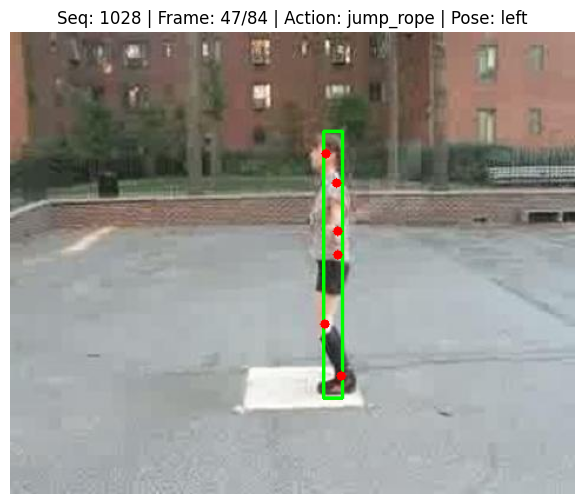

KeyboardInterrupt: 

In [ ]:
sequence_id = '1511'  

frame_idx = 0

mat_data = sio.loadmat(os.path.join(LABELS_DIR, f'{sequence_id}.mat'))

visualize_sequence(sequence_id, mat_data, FRAMES_DIR, delay=0.1)

In [ ]:
def draw_pose_on_image(img, joints_x, joints_y, vis, pose_names, skeleton):
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
    return img

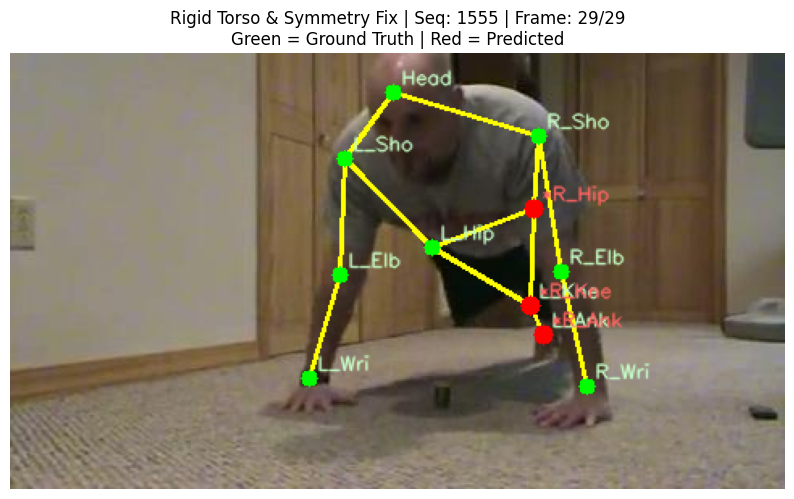

In [ ]:
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1555' # The sequence with the "flying" head 

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img = draw_pose_on_image(img, joints_x, joints_y, vis, pose_names, skeleton)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

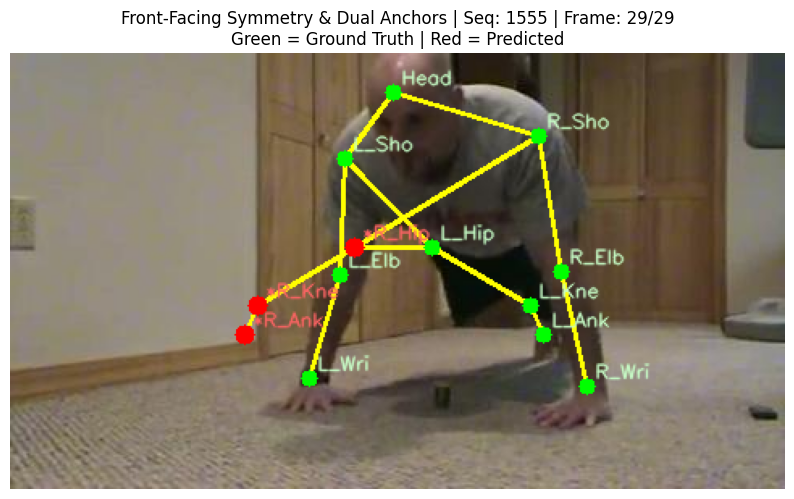

In [ ]:
sequence_id = '1555' # Pushup sequence

n_frames = mat_data['nframes'][0][0]


raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# Interpolate the Head first so we can use it as a mirror axis
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

for f in range(n_frames):
    head_x = df.at[f, 'Head_x']
    
    # Mirror missing joints across the vertical axis of the head
    for joint in ['Sho', 'Elb', 'Wri', 'Hip', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = head_x - (df.at[f, r_x] - head_x) # Mirror Left
            
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = head_x + (head_x - df.at[f, l_x]) # Mirror Right


upper_joints = ['L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri']
lower_joints = ['L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

# 1. Establish the Lower Body Anchor (Mid-Hip)
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1).interpolate(method='linear', limit_direction='both')
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1).interpolate(method='linear', limit_direction='both')

# 2. Anchor UPPER body to the HEAD
for name in upper_joints: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# 3. Anchor LOWER body to the HIPS (Prevents feet/knees from sinking with the head)
for name in lower_joints:
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Mid_Hip_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Mid_Hip_y']
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Mid_Hip_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Mid_Hip_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Front-Facing Symmetry & Dual Anchors | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

In [ ]:
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# Columns we want to keep for the final CSV export
final_columns = []
for name in pose_names:
    final_columns.append(f'{name}_x')
    final_columns.append(f'{name}_y')

# This list will hold the DataFrames for all 200+ videos
all_pushup_data = []

start_seq = 1348
end_seq = 1557

print(f"Starting batch process for sequences {start_seq} to {end_seq}...")

for seq_num in range(start_seq, end_seq + 1):
    sequence_id = f"{seq_num:04d}"
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    
    # Skip if the .mat file doesn't exist
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Double check to ensure it's actually a pushup video
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action not in ['pushup', 'pushups']: 
        continue
        
    n_frames = mat_data['nframes'][0][0]

    # ==========================================
    # STEP 1: LOAD ALL FRAMES 
    # ==========================================
    raw_data = []
    for f in range(n_frames):
        jx = mat_data['x'][f].astype(float)
        jy = mat_data['y'][f].astype(float)
        vis = mat_data['visibility'][f]
        
        row = {}
        for i in range(13):
            if vis[i] == 1:
                row[f'{pose_names[i]}_x'] = jx[i]
                row[f'{pose_names[i]}_y'] = jy[i]
            else:
                row[f'{pose_names[i]}_x'] = np.nan
                row[f'{pose_names[i]}_y'] = np.nan
        raw_data.append(row)

    df = pd.DataFrame(raw_data)

    # ==========================================
    # STEP 1.5: FRONT-FACING MIRROR SYMMETRY
    # ==========================================
    df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

    for f in range(n_frames):
        head_x = df.at[f, 'Head_x']
        
        for joint in ['Sho', 'Elb', 'Wri', 'Hip', 'Kne', 'Ank']:
            r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
            l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
            
            if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
                df.at[f, l_y] = df.at[f, r_y]
                df.at[f, l_x] = head_x - (df.at[f, r_x] - head_x) 
                
            elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
                df.at[f, r_y] = df.at[f, l_y]
                df.at[f, r_x] = head_x + (head_x - df.at[f, l_x]) 

    # ==========================================
    # STEP 2: DUAL-ANCHOR RELATIVE INTERPOLATION
    # ==========================================
    upper_joints = ['L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri']
    lower_joints = ['L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

    df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1).interpolate(method='linear', limit_direction='both')
    df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1).interpolate(method='linear', limit_direction='both')

    for name in upper_joints: 
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

    for name in lower_joints:
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Mid_Hip_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Mid_Hip_y']
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Mid_Hip_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Mid_Hip_y']

    # ==========================================
    # STEP 3: PREPARE FOR CONCATENATION
    # ==========================================
    # Filter out the temporary calculation columns
    df_export = df[final_columns].copy()
    
    # Add Sequence_ID and Frame columns to the very front
    df_export.insert(0, 'Frame', df_export.index + 1)
    df_export.insert(0, 'Sequence_ID', sequence_id)
    
    # Round coordinates to 3 decimals to keep the CSV clean
    df_export = df_export.round(3)
    
    # Append this processed sequence to our master list
    all_pushup_data.append(df_export)
    
    # Print progress
    if seq_num % 20 == 0:
        print(f"Processed up to sequence {sequence_id}...")

# ==========================================
# STEP 4: COMBINE AND EXPORT
# ==========================================
print("\nCombining all sequences into a single file...")

# Concatenate all DataFrames into one massive dataset
final_df = pd.concat(all_pushup_data, ignore_index=True)

# Export to a single CSV
final_csv_name = 'pushups_coords_1348_1557.csv'
final_df.to_csv(final_csv_name, index=False)

print(f"Success! Saved {len(final_df)} total frames across {len(all_pushup_data)} sequences to '{final_csv_name}'.")
display(final_df.head())

Starting batch process for sequences 1348 to 1557...
Processed up to sequence 1360...
Processed up to sequence 1380...
Processed up to sequence 1400...
Processed up to sequence 1420...
Processed up to sequence 1440...
Processed up to sequence 1460...
Processed up to sequence 1480...
Processed up to sequence 1500...
Processed up to sequence 1520...
Processed up to sequence 1540...

Combining all sequences into a single file...
Success! Saved 10453 total frames across 210 sequences to 'all_pushups_interpolated_1348_1557.csv'.


,Sequence_ID,Frame,Head_x,Head_y,L_Sho_x,L_Sho_y,R_Sho_x,R_Sho_y,L_Elb_x,L_Elb_y,...,R_Hip_x,R_Hip_y,L_Kne_x,L_Kne_y,R_Kne_x,R_Kne_y,L_Ank_x,L_Ank_y,R_Ank_x,R_Ank_y
0,1348,1,78.0,46.5,-76.5,48.0,232.5,48.0,154.5,129.0,...,325.5,103.5,-208.5,124.5,364.5,124.5,-232.5,121.5,388.5,121.5
1,1348,2,75.0,63.0,-81.0,58.5,231.0,58.5,154.5,135.0,...,325.5,108.0,-214.5,129.0,364.5,129.0,-238.5,121.5,388.5,121.5
2,1348,3,84.0,84.0,-61.5,70.5,229.5,70.5,-145.5,171.0,...,325.5,112.5,-195.0,130.5,363.0,130.5,-220.5,121.5,388.5,121.5
3,1348,4,81.0,100.5,-66.0,84.0,228.0,84.0,-157.5,175.5,...,327.0,123.0,-199.5,133.5,361.5,133.5,-225.0,121.5,387.0,121.5
4,1348,5,76.5,118.5,-72.0,103.5,225.0,103.5,-171.0,180.0,...,327.0,127.5,-207.0,135.0,360.0,135.0,-234.0,123.0,387.0,123.0


In [ ]:
all_joints_data = []
all_angles_data = []

print("Starting batch process for Pushup sequences...")

for seq_num in range(1, 2327):
    sequence_id = f"{seq_num:04d}"
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    if not os.path.exists(mat_path): continue
        
    mat_data = sio.loadmat(mat_path)
    action_str = str(mat_data['action']).lower()
    
    # Check for pushup action
    if 'pushup' not in action_str and 'push-up' not in action_str: continue
        
    n_frames = mat_data['nframes'][0][0]

    # 1. LOAD RAW DATA
    raw_rows = []
    for f in range(n_frames):
        row = {'Sequence_ID': sequence_id, 'Frame': f + 1}
        jx, jy, vis = mat_data['x'][f], mat_data['y'][f], mat_data['visibility'][f]
        for i, name in enumerate(pose_names):
            if vis[i] == 1:
                row[f'{name}_x'], row[f'{name}_y'] = float(jx[i]), float(jy[i])
            else:
                row[f'{name}_x'], row[f'{name}_y'] = np.nan, np.nan
        raw_rows.append(row)
    df = pd.DataFrame(raw_rows)

    # 2. PREDICT MISSING POINTS (The requested method)
    df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
    df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)
    
    valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
    true_ty = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median() if not valid_torso.empty else 50.0
    true_tx = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median() if not valid_torso.empty else 150.0

    for f in range(n_frames):
        if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
            df.at[f, 'Head_y'], df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_y'] - true_ty, df.at[f, 'Mid_Hip_x'] - true_tx
    
    df['Head_x'] = df['Head_x'].interpolate(limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(limit_direction='both')

    for f in range(n_frames):
        hy, hx = df.at[f, 'Head_y'], df.at[f, 'Head_x']
        for j in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
            ry, rx, ly, lx = f'R_{j}_y', f'R_{j}_x', f'L_{j}_y', f'L_{j}_x'
            if not pd.isna(df.at[f, ry]) and pd.isna(df.at[f, ly]):
                df.at[f, ly], df.at[f, lx] = df.at[f, ry], df.at[f, rx]
            elif not pd.isna(df.at[f, ly]) and pd.isna(df.at[f, ry]):
                df.at[f, ry], df.at[f, rx] = df.at[f, ly], df.at[f, lx]
        
        # Proportional build adjusted for horizontal orientation
        if pd.isna(df.at[f, 'R_Sho_y']):
            df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = hy + (true_ty * 0.2)
            df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = hx

    # Anchor-based Relative Interpolation
    for name in pose_names[1:]: 
        df[f'{name}_x'] = (df[f'{name}_x'] - df['Head_x']).interpolate(limit_direction='both') + df['Head_x']
        df[f'{name}_y'] = (df[f'{name}_y'] - df['Head_y']).interpolate(limit_direction='both') + df['Head_y']

    all_joints_data.append(df.copy())

    # 3. KINEMATICS & ANGLE CALCULATIONS
    # Determine viewpoint (Pushups: Shoulder width vs Torso length)
    avg_sw = abs(df['L_Sho_x'] - df['R_Sho_x']).mean()
    avg_tl = abs(df['Head_x'] - df['Mid_Hip_x']).mean()
    pose_type = 'Front/Back' if avg_sw > (avg_tl * 0.5) else 'Side'

    # Baseline frame (Plank position - max distance Head to Ankles)
    df['Mid_Ank_x'] = df[['L_Ank_x', 'R_Ank_x']].mean(axis=1)
    df['Total_Len'] = np.sqrt((df['Head_x']-df['Mid_Ank_x'])**2 + (df['Head_y']-df['Mid_Ank_y'])**2) if 'Mid_Ank_y' in df else abs(df['Head_x'] - df['Mid_Hip_x'])
    
    if df['Total_Len'].isna().all():
        stand_idx = 0
    else:
        stand_idx = df['Total_Len'].idxmax()
    
    sr = df.iloc[stand_idx]
    
    # Baseline Segment Lengths for Arcsin method
    base = compute_baselines(sr)

    all_angles_data.extend(compute_all_angles(df, sequence_id, pose_type, base))

    if seq_num % 100 == 0: print(f"Processed up to {sequence_id}...")

# EXPORT
export_joints_and_angles(all_joints_data, all_angles_data, 'pushup')

In [ ]:
# Summarize and normalize pushup data
summarize_and_normalize('pushup')

# PullUP


In [ ]:
sequence_id = '1180'  

frame_idx = 0

mat_data = sio.loadmat(os.path.join(LABELS_DIR, f'{sequence_id}.mat'))

visualize_sequence(sequence_id, mat_data, FRAMES_DIR, delay=0.1)

KeyboardInterrupt: 

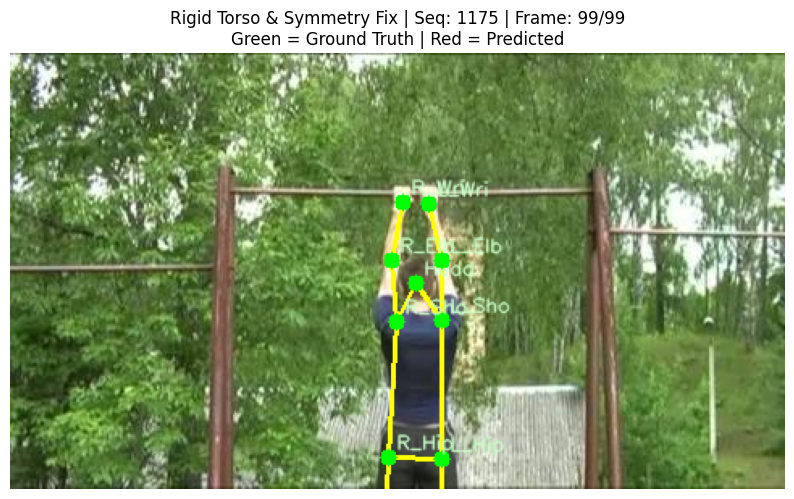

In [ ]:
sequence_id = '1175' # The sequence with the "flying" head

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

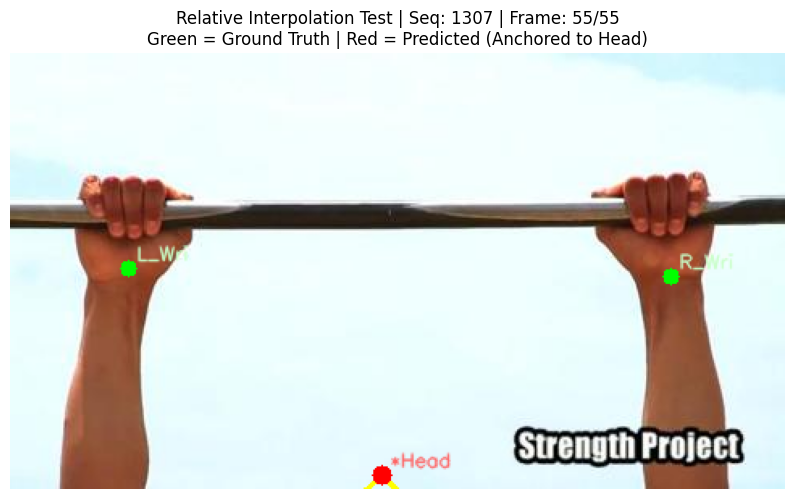

In [ ]:
sequence_id = '1307' # A bowling sequence

n_frames = mat_data['nframes'][0][0]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
# 1. First, interpolate the Anchor (Head) perfectly across the whole video.
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# 2. Convert all other joints to be RELATIVE to the Head
for name in pose_names[1:]: # Skip the Head itself
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

# 3. Interpolate the RELATIVE coordinates (bridging the gap in local body space)
for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

# 4. Reconstruct the absolute coordinates by adding the moving Head back!
for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    # Grab the newly calculated relative-interpolated coordinates
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    # Load Image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines 
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED joints via Relative Interpolation in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Relative Interpolation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted (Anchored to Head)")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

In [ ]:
all_joints_data = []
all_angles_data = []

print("Starting batch process for Pullup sequences...")

for seq_num in range(1, 2327):
    sequence_id = f"{seq_num:04d}"
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    if not os.path.exists(mat_path): continue
        
    mat_data = sio.loadmat(mat_path)
    action_str = str(mat_data['action']).lower()
    
    # Target pullups
    if 'pullup' not in action_str and 'pull-up' not in action_str: continue
        
    n_frames = mat_data['nframes'][0][0]

    # 1. LOAD RAW DATA
    raw_rows = []
    for f in range(n_frames):
        row = {'Sequence_ID': sequence_id, 'Frame': f + 1}
        jx, jy, vis = mat_data['x'][f], mat_data['y'][f], mat_data['visibility'][f]
        for i, name in enumerate(pose_names):
            if vis[i] == 1:
                row[f'{name}_x'], row[f'{name}_y'] = float(jx[i]), float(jy[i])
            else:
                row[f'{name}_x'], row[f'{name}_y'] = np.nan, np.nan
        raw_rows.append(row)
    df = pd.DataFrame(raw_rows)

    # 2. IDENTIFY THE "BEST FRAME" TO BUILD MISSING ANATOMY
    # Count how many joints are visible in each frame
    point_counts = df[[f'{n}_x' for n in pose_names]].count(axis=1)
    if point_counts.max() == 0: continue # Skip if the video is completely blank
    
    best_idx = point_counts.idxmax()
    
    # Ensure symmetry on the best frame first
    for j in ['Sho', 'Elb', 'Wri', 'Hip', 'Kne', 'Ank']:
        ry, rx, ly, lx = f'R_{j}_y', f'R_{j}_x', f'L_{j}_y', f'L_{j}_x'
        if not pd.isna(df.at[best_idx, ry]) and pd.isna(df.at[best_idx, ly]):
            df.at[best_idx, ly], df.at[best_idx, lx] = df.at[best_idx, ry], df.at[best_idx, rx]
        elif not pd.isna(df.at[best_idx, ly]) and pd.isna(df.at[best_idx, ry]):
            df.at[best_idx, ry], df.at[best_idx, rx] = df.at[best_idx, ly], df.at[best_idx, lx]

    # --- Structural Fallback Constraints (Pixels) ---
    def_sw = 100.0  # Shoulder width
    def_tl = 150.0  # Torso length
    def_ll = 150.0  # Leg length

    # Head Check (Crucial Anchor)
    if pd.isna(df.at[best_idx, 'Head_x']):
        if not pd.isna(df.at[best_idx, 'L_Sho_x']):
            df.at[best_idx, 'Head_x'] = (df.at[best_idx, 'L_Sho_x'] + df.at[best_idx, 'R_Sho_x']) / 2
            df.at[best_idx, 'Head_y'] = (df.at[best_idx, 'L_Sho_y'] + df.at[best_idx, 'R_Sho_y']) / 2 - 50
        else:
            df.at[best_idx, 'Head_x'], df.at[best_idx, 'Head_y'] = 250.0, 150.0 # Absolute worst-case fallback

    hx, hy = df.at[best_idx, 'Head_x'], df.at[best_idx, 'Head_y']

    # Build Missing Parts Downward & Upward on Best Frame
    if pd.isna(df.at[best_idx, 'L_Sho_x']):
        df.at[best_idx, 'L_Sho_x'], df.at[best_idx, 'L_Sho_y'] = hx + def_sw/2, hy + 50
        df.at[best_idx, 'R_Sho_x'], df.at[best_idx, 'R_Sho_y'] = hx - def_sw/2, hy + 50

    ms_x = (df.at[best_idx, 'L_Sho_x'] + df.at[best_idx, 'R_Sho_x']) / 2
    ms_y = (df.at[best_idx, 'L_Sho_y'] + df.at[best_idx, 'R_Sho_y']) / 2

    # Wrists (Pullups: hands are ABOVE the head)
    if pd.isna(df.at[best_idx, 'L_Wri_x']):
        df.at[best_idx, 'L_Wri_x'], df.at[best_idx, 'L_Wri_y'] = df.at[best_idx, 'L_Sho_x'], hy - 80
        df.at[best_idx, 'R_Wri_x'], df.at[best_idx, 'R_Wri_y'] = df.at[best_idx, 'R_Sho_x'], hy - 80

    # Elbows (Between shoulder and wrist, slightly bowed out)
    if pd.isna(df.at[best_idx, 'L_Elb_x']):
        df.at[best_idx, 'L_Elb_x'] = (df.at[best_idx, 'L_Sho_x'] + df.at[best_idx, 'L_Wri_x']) / 2 + 20 
        df.at[best_idx, 'L_Elb_y'] = (df.at[best_idx, 'L_Sho_y'] + df.at[best_idx, 'L_Wri_y']) / 2
        df.at[best_idx, 'R_Elb_x'] = (df.at[best_idx, 'R_Sho_x'] + df.at[best_idx, 'R_Wri_x']) / 2 - 20
        df.at[best_idx, 'R_Elb_y'] = (df.at[best_idx, 'R_Sho_y'] + df.at[best_idx, 'R_Wri_y']) / 2

    # Hips, Knees, Ankles (Hanging straight down)
    if pd.isna(df.at[best_idx, 'L_Hip_x']):
        df.at[best_idx, 'L_Hip_x'], df.at[best_idx, 'L_Hip_y'] = df.at[best_idx, 'L_Sho_x'], ms_y + def_tl
        df.at[best_idx, 'R_Hip_x'], df.at[best_idx, 'R_Hip_y'] = df.at[best_idx, 'R_Sho_x'], ms_y + def_tl
    if pd.isna(df.at[best_idx, 'L_Kne_x']):
        df.at[best_idx, 'L_Kne_x'], df.at[best_idx, 'L_Kne_y'] = df.at[best_idx, 'L_Hip_x'], df.at[best_idx, 'L_Hip_y'] + def_ll
        df.at[best_idx, 'R_Kne_x'], df.at[best_idx, 'R_Kne_y'] = df.at[best_idx, 'R_Hip_x'], df.at[best_idx, 'R_Hip_y'] + def_ll
    if pd.isna(df.at[best_idx, 'L_Ank_x']):
        df.at[best_idx, 'L_Ank_x'], df.at[best_idx, 'L_Ank_y'] = df.at[best_idx, 'L_Kne_x'], df.at[best_idx, 'L_Kne_y'] + def_ll
        df.at[best_idx, 'R_Ank_x'], df.at[best_idx, 'R_Ank_y'] = df.at[best_idx, 'R_Kne_x'], df.at[best_idx, 'R_Kne_y'] + def_ll

    # 3. ANCHOR-BASED RELATIVE INTERPOLATION
    # Smooth the head out across all frames first
    df['Head_x'] = df['Head_x'].interpolate(limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(limit_direction='both')

    # Convert to relative, interpolate, convert back
    for name in pose_names[1:]: 
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']
        
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(limit_direction='both')
        
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']
        
        # Drop the temp relative columns to keep DataFrame clean
        df.drop(columns=[f'{name}_rel_x', f'{name}_rel_y'], inplace=True)

    all_joints_data.append(df.copy().round(3))

    # 4. VIEWPOINT DETECTION & BASELINES
    avg_sw = abs(df['L_Sho_x'] - df['R_Sho_x']).mean()
    avg_tl = abs(df['Head_y'] - df['L_Hip_y']).mean()
    pose_type = 'Front/Back' if avg_sw > (avg_tl * 0.40) else 'Side'

    # Pullup Baseline Frame (Max downward extension, where arms are straightest)
    # We find the frame where Head is furthest away from the Wrists
    df['Mid_Wri_y'] = df[['L_Wri_y', 'R_Wri_y']].mean(axis=1)
    df['Hang_Dist'] = abs(df['Mid_Wri_y'] - df['Head_y'])
    
    stand_idx = df['Hang_Dist'].idxmax() if not df['Hang_Dist'].isna().all() else 0
    sr = df.iloc[stand_idx]
    
    base = compute_baselines(sr)

    # 5. KINEMATIC ANGLE CALCULATION
    all_angles_data.extend(compute_all_angles(df, sequence_id, pose_type, base))

    if seq_num % 100 == 0: print(f"Processed up to {sequence_id}...")

# EXPORT
export_joints_and_angles(all_joints_data, all_angles_data, 'pullup')

In [ ]:
# Summarize and normalize pullup data
summarize_and_normalize('pullup')